In [49]:
import pandas as pd 
import matplotlib.pyplot as plt 


df = pd.read_csv('/Users/margarita/Downloads/fraud_dataset.csv')
print(df.head())


   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [2]:
df.shape

(6362620, 11)

In [3]:
df.info

<bound method DataFrame.info of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1

In [4]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [5]:
isFraud = df['isFraud'].value_counts()
print(isFraud)

isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [6]:
fraud_rate = df['isFraud'].mean() * 100
print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 0.13%


In [7]:
fraud_rate = (
    df['isFraud'].sum()
    / len(df)
    * 100
)
print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 0.13%


In [8]:
total_transactions = len(df)

fraud_transactions = df['isFraud'].sum()

fraud_rate = fraud_transactions / total_transactions * 100

print(f'Total transactions: {total_transactions:,}')
print(f'Fraud transactions: {fraud_transactions:,}')
print(f'Fraud rate: {fraud_rate:.4f}%')

Total transactions: 6,362,620
Fraud transactions: 8,213
Fraud rate: 0.1291%


In [9]:
df.groupby('type').agg(
    transactions=('isFraud', 'count'),
    fraud_transactions=('isFraud', 'sum'),
    avg_amount=('amount', 'mean')
)

,transactions,fraud_transactions,avg_amount
type,,,
CASH_IN,1399284,0,168920.242004
CASH_OUT,2237500,4116,176273.964346
DEBIT,41432,0,5483.665314
PAYMENT,2151495,0,13057.604660
TRANSFER,532909,4097,910647.009645


In [14]:
df.groupby('type').agg(
    transactions=('type', 'count'),
     mean_amount=('amount', 'mean'),  
     median_amount=('amount', 'median'),
     max_amount=('amount', 'max')
    ).reset_index()


,type,transactions,mean_amount,median_amount,max_amount
0,CASH_IN,1399284,168920.242004,143427.710,1915267.90
1,CASH_OUT,2237500,176273.964346,147072.185,10000000.00
2,DEBIT,41432,5483.665314,3048.990,569077.51
3,PAYMENT,2151495,13057.604660,9482.190,238637.98
4,TRANSFER,532909,910647.009645,486308.390,92445516.64


In [13]:
df['type'].value_counts()


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [17]:
print(df.isna().sum())
print(df.duplicated().sum())
df.dtypes

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
0


step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [22]:
df.groupby('isFraud').agg(
    transactions=('isFraud', 'count'),
    avg_amount=('amount', 'mean'),
    median_amount=('amount', 'median')
).reset_index()


,isFraud,transactions,avg_amount,median_amount
0,0,6354407,1.781970e+05,74684.72
1,1,8213,1.467967e+06,441423.44


In [23]:
df.groupby('type').agg(
    transactions=('isFraud', 'count'),
    fraud_transactions=('isFraud', 'sum'),
    avg_amount=('amount', 'mean'),
    fraud_rate=('isFraud', 'mean')
).reset_index() 

,type,transactions,fraud_transactions,avg_amount,fraud_rate
0,CASH_IN,1399284,0,168920.242004,0.000000
1,CASH_OUT,2237500,4116,176273.964346,0.001840
2,DEBIT,41432,0,5483.665314,0.000000
3,PAYMENT,2151495,0,13057.604660,0.000000
4,TRANSFER,532909,4097,910647.009645,0.007688


In [24]:
df['amount'].describe() 


count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [29]:
top10 = df.sort_values('amount', ascending=False).head(10)
print(top10[['amount', 'isFraud']])



              amount  isFraud
3686583  92445516.64        0
4060598  73823490.36        0
4146397  71172480.42        0
3946920  69886731.30        0
3911956  69337316.27        0
3937152  67500761.29        0
4105338  66761272.21        0
3892529  64234448.19        0
3991638  63847992.58        0
4143801  63294839.63        0


In [31]:
top10fraud = df[df['isFraud'] == 1].sort_values('amount', ascending=False).head(10)
print(top10fraud[['amount', 'isFraud']])


             amount  isFraud
6362576  10000000.0        1
4441     10000000.0        1
3247294  10000000.0        1
3247295  10000000.0        1
3247296  10000000.0        1
4440     10000000.0        1
6362583  10000000.0        1
1030662  10000000.0        1
1030661  10000000.0        1
1030688  10000000.0        1


In [37]:
print(df['nameOrig'].nunique())

print(df['nameDest'].nunique())     

6353307
2722362


In [40]:
df['nameOrig'].value_counts().head(10)

nameOrig
C724452879     3
C1677795071    3
C1902386530    3
C1530544995    3
C1784010646    3
C1976208114    3
C545315117     3
C1065307291    3
C1999539787    3
C400299098     3
Name: count, dtype: int64

In [57]:
fraud_by_type = df.groupby('type').agg(
    transactions=('isFraud', 'count'),
    fraud_transactions=('isFraud', 'sum'),
    fraud_rate=('isFraud', 'mean')
    
).reset_index()

print(fraud_by_type)

       type  transactions  fraud_transactions  fraud_rate
0   CASH_IN       1399284                   0    0.000000
1  CASH_OUT       2237500                4116    0.001840
2     DEBIT         41432                   0    0.000000
3   PAYMENT       2151495                   0    0.000000
4  TRANSFER        532909                4097    0.007688


In [44]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [45]:
df['balance_change'] = (
    df['oldbalanceOrg']
    - df['newbalanceOrig']
)

df.groupby('isFraud')['balance_change'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-2.314152e+04,1.062233e+05,-1915267.9,0.00,0.00,10102.125,4164236.31
1,8213.0,1.457275e+06,2.396099e+06,0.0,124582.58,436317.49,1503034.860,10000000.00


In [46]:
df['account_drained'] = (
    (df['oldbalanceOrg'] > 0)
    & (df['newbalanceOrig'] == 0)
)




pd.crosstab(
    df['account_drained'],
    df['isFraud']
)

isFraud,0,1
account_drained,,
False,4841838,201
True,1512569,8012


<Axes: xlabel='type'>

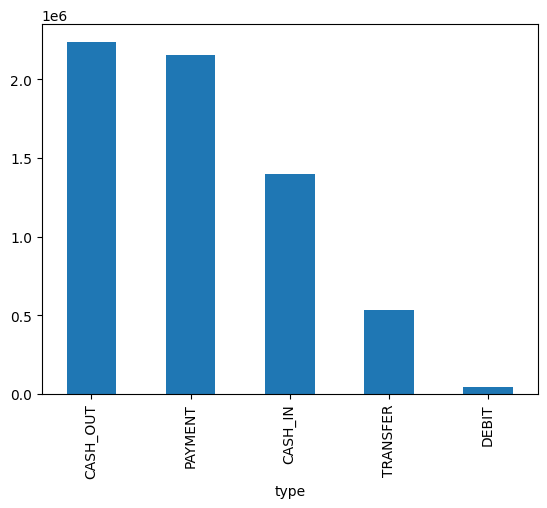

In [47]:
df['type'].value_counts().plot(kind='bar')

<Axes: >

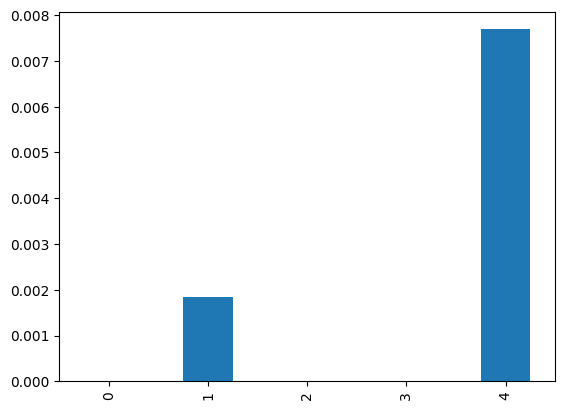

In [58]:
fraud_by_type['fraud_rate'].plot(kind='bar')


<Axes: xlabel='isFraud'>

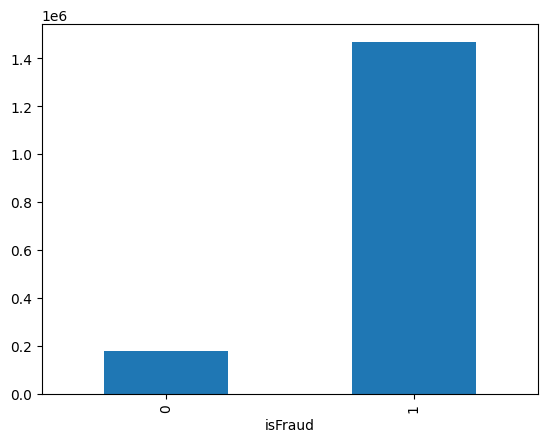

In [59]:
df.groupby('isFraud')['amount'].mean().plot(kind='bar')

<Axes: xlabel='step'>

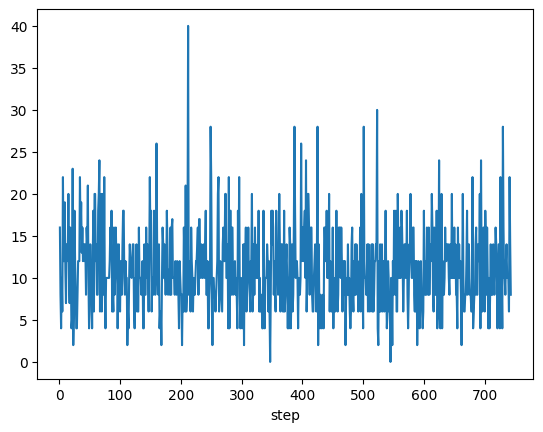

In [61]:
fraud_by_step = (
    df.groupby('step')['isFraud']
    .sum()
)

fraud_by_step.plot()

,transactions,fraud_count
type,,
CASH_IN,1399284,0
CASH_OUT,2237500,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,532909,4097
